# Price Elasticity of Liquor Demand by Category and County in Iowa
## Demand Analytics — Final Project

---

## Research Questions

> **Main:** How sensitive is liquor demand to price changes across counties and product categories in Iowa?
>
> **Secondary:** Do holidays and weekends amplify or weaken that price sensitivity?

Rather than treating liquor sales as a revenue accounting exercise, this notebook frames the problem as a **demand modeling problem**: demand is a function of price, market characteristics, and time structure. We estimate price elasticities using a log-log regression framework with county, category, month, and year fixed effects — following the aggregate and dynamic demand frameworks from course material.

---

## Model Roadmap

| Group | Models | Core Question |
|---|---|---|
| Functional Form | M0 Linear, M1 Semi-log, M2 Log-log, M3 Quadratic | What shape best describes price-demand? |
| Heterogeneity | M4 Category, M5 Urban/Rural, M6 Cat × Market | Who is price sensitive? |
| Calendar | M7 Holiday Interaction, M8 Month × Price, M9 Year Trend | When does sensitivity change? |
| Dynamic | M10 Lagged Demand, M11 Lagged Price | Does past demand/price predict today? |
| Cross-Price | M12 Vodka ↔ Whiskey | Are spirits substitutes? |

---
# 1. Setup

Install any missing packages by running:
```
pip install pyfixest pandas numpy matplotlib seaborn statsmodels
```

We use **`pyfixest`** as our primary modeling package — it is the Python equivalent of R's `fixest` and is purpose-built for high-dimensional fixed effects panel models. It is dramatically faster than including dummy variables manually in statsmodels.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import pyfixest as pf

warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='tab10')

DATA_PATH = 'cleaned_iowa_liquor_sales_merged.csv'

print('All packages loaded.')

All packages loaded.


---
# 2. Data Loading & Preparation

The raw dataset contains **12.3 million** individual liquor transactions across 99 Iowa counties from 2012–2017. Three columns use dollar formatting (`$X.XX`) and must be parsed to numeric. We compute `price_per_liter` at the transaction level before aggregating.

In [4]:
print('Loading raw data... (this may take ~30 seconds for 12M rows)')

df = pd.read_csv(DATA_PATH, low_memory=False)

# --- Parse dollar-formatted columns ---
for col in ['State Bottle Cost', 'State Bottle Retail', 'Sale (Dollars)']:
    df[col] = df[col].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# --- Date and time features ---
df['date']  = pd.to_datetime(df['Date'])
df['month'] = df['date'].dt.month
df['year']  = df['Year'].astype(int)
df['ym']    = df['date'].dt.to_period('M').astype(str)  # e.g. '2015-11'

# --- Price per liter at transaction level (retail price / volume in liters) ---
df['price_per_liter'] = df['State Bottle Retail'] / (df['Bottle Volume (ml)'] / 1000)
df = df[(df['price_per_liter'] > 0) & np.isfinite(df['price_per_liter'])]

print(f'Rows after cleaning: {len(df):,}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Counties: {df["County"].nunique()} | Raw categories: {df["Category Name"].nunique()}')

Loading raw data... (this may take ~30 seconds for 12M rows)
Rows after cleaning: 12,297,359
Date range: 2012-01-03 to 2017-10-31
Counties: 99 | Raw categories: 130


## 2.1 Category Consolidation

The raw data has 130 granular category names. We consolidate into **8 broad spirit categories** to ensure enough observations per group for reliable elasticity estimation.

In [5]:
cat_map = {
    # Vodka
    '100 PROOF VODKA': 'Vodka', 'VODKA 80 PROOF': 'Vodka',
    'VODKA FLAVORED': 'Vodka', 'IMPORTED VODKA': 'Vodka',
    'IMPORTED VODKA - MISC': 'Vodka', 'LOW PROOF VODKA': 'Vodka',
    'OTHER PROOF VODKA': 'Vodka',
    # Whiskey
    'BLENDED WHISKIES': 'Whiskey', 'CANADIAN WHISKIES': 'Whiskey',
    'IRISH WHISKIES': 'Whiskey', 'SCOTCH WHISKIES': 'Whiskey',
    'SINGLE MALT SCOTCH': 'Whiskey', 'STRAIGHT BOURBON WHISKIES': 'Whiskey',
    'STRAIGHT RYE WHISKIES': 'Whiskey', 'TENNESSEE WHISKIES': 'Whiskey',
    'BOTTLED IN BOND BOURBON': 'Whiskey',
    'SINGLE BARREL BOURBON WHISKIES': 'Whiskey',
    'WHISKEY LIQUEUR': 'Whiskey', 'ROCK & RYE': 'Whiskey',
    # Rum
    'BARBADOS RUM': 'Rum', 'FLAVORED RUM': 'Rum', 'JAMAICA RUM': 'Rum',
    'PUERTO RICO & VIRGIN ISLANDS RUM': 'Rum', 'SPICED RUM': 'Rum',
    # Tequila
    'TEQUILA': 'Tequila',
    # Gin
    'AMERICAN DRY GINS': 'Gin', 'AMERICAN SLOE GINS': 'Gin',
    'FLAVORED GINS': 'Gin', 'IMPORTED DRY GINS': 'Gin',
    # Brandy
    'AMERICAN GRAPE BRANDIES': 'Brandy', 'APRICOT BRANDIES': 'Brandy',
    'BLACKBERRY BRANDIES': 'Brandy', 'CHERRY BRANDIES': 'Brandy',
    'IMPORTED GRAPE BRANDIES': 'Brandy', 'MISCELLANEOUS BRANDIES': 'Brandy',
    'PEACH BRANDIES': 'Brandy',
    # Schnapps
    'APPLE SCHNAPPS': 'Schnapps', 'BUTTERSCOTCH SCHNAPPS': 'Schnapps',
    'CINNAMON SCHNAPPS': 'Schnapps', 'GRAPE SCHNAPPS': 'Schnapps',
    'IMPORTED SCHNAPPS': 'Schnapps', 'MISCELLANEOUS SCHNAPPS': 'Schnapps',
    'PEACH SCHNAPPS': 'Schnapps', 'PEPPERMINT SCHNAPPS': 'Schnapps',
    'RASPBERRY SCHNAPPS': 'Schnapps', 'ROOT BEER SCHNAPPS': 'Schnapps',
    'SPEARMINT SCHNAPPS': 'Schnapps', 'STRAWBERRY SCHNAPPS': 'Schnapps',
    'TROPICAL FRUIT SCHNAPPS': 'Schnapps', 'WATERMELON SCHNAPPS': 'Schnapps',
    # Liqueurs
    'AMERICAN AMARETTO': 'Liqueurs', 'AMERICAN COCKTAILS': 'Liqueurs',
    'ANISETTE': 'Liqueurs', 'COFFEE LIQUEURS': 'Liqueurs',
    'CREAM LIQUEURS': 'Liqueurs', 'CREME DE ALMOND': 'Liqueurs',
    'DARK CREME DE CACAO': 'Liqueurs', 'GREEN CREME DE MENTHE': 'Liqueurs',
    'IMPORTED AMARETTO': 'Liqueurs',
    'MISC. AMERICAN CORDIALS & LIQUEURS': 'Liqueurs',
    'MISC. IMPORTED CORDIALS & LIQUEURS': 'Liqueurs',
    'TRIPLE SEC': 'Liqueurs', 'WHITE CREME DE CACAO': 'Liqueurs',
    'WHITE CREME DE MENTHE': 'Liqueurs',
    # Other
    'AMERICAN ALCOHOL': 'Other', 'DECANTERS & SPECIALTY PACKAGES': 'Other',
    'DISTILLED SPIRITS SPECIALTY': 'Other',
}

df['category'] = df['Category Name'].map(cat_map)
df = df.dropna(subset=['category'])

print(f'Rows after category mapping: {len(df):,}')
print(f'Categories: {sorted(df["category"].unique())}')

Rows after category mapping: 9,786,815
Categories: ['Brandy', 'Gin', 'Liqueurs', 'Other', 'Rum', 'Schnapps', 'Tequila', 'Vodka', 'Whiskey']


## 2.2 Aggregate to Panel

The unit of analysis is **county × year-month × category**. At this level we compute total liters, average price per liter, and the key dependent variable: **liters sold per adult (age 20+)**. Normalizing by adult population makes county comparisons meaningful — otherwise large counties will always appear to dominate.

**Why liters per adult?** A county selling 10,000 liters with 200,000 adults has lower per-capita demand than a county selling 8,000 liters with 50,000 adults. Raw volume misleads; per-adult demand does not.

In [6]:
# --- Holiday/weekend days per month (calendar feature, not county-specific) ---
holiday_per_month = (
    df[df['Is_Holiday_Weekend'] == 1]
    .groupby('ym')['date']
    .nunique()
    .reset_index(name='holiday_days')
)

# --- Aggregate to county x ym x category ---
panel = (
    df.groupby(['County', 'ym', 'category', 'year', 'month'])
    .agg(
        total_liters  = ('Volume Sold (Liters)', 'sum'),
        total_bottles = ('Bottles Sold', 'sum'),
        total_sales   = ('Sale (Dollars)', 'sum'),
        population    = ('Population', 'first'),
    )
    .reset_index()
)

# Revenue-weighted average price per liter = total_sales / total_liters
panel['avg_price_liter'] = panel['total_sales'] / panel['total_liters']

# Merge holiday days
panel = panel.merge(holiday_per_month, on='ym', how='left')
panel['holiday_days'] = panel['holiday_days'].fillna(0)

# --- Key variables ---
panel['liters_per_adult'] = panel['total_liters'] / panel['population']

# Drop zero/negative demand or price (can't log-transform)
panel = panel[(panel['liters_per_adult'] > 0) & (panel['avg_price_liter'] > 0)]

# Log transformations
panel['log_liters_pa'] = np.log(panel['liters_per_adult'])
panel['log_price']     = np.log(panel['avg_price_liter'])
panel['log_price_sq']  = panel['log_price'] ** 2

# Market type (based on adult population)
panel['market_type'] = pd.cut(
    panel['population'],
    bins=[0, 30_000, 100_000, np.inf],
    labels=['Rural', 'Suburban', 'Urban']
).astype(str)

# Rename County for clean formula syntax
panel = panel.rename(columns={'County': 'county'})

# Sort and create lags within each county-category group
panel = panel.sort_values(['county', 'category', 'ym']).reset_index(drop=True)
panel['log_liters_pa_lag'] = panel.groupby(['county', 'category'])['log_liters_pa'].shift(1)
panel['log_price_lag']     = panel.groupby(['county', 'category'])['log_price'].shift(1)

# Year centered (for year-trend model — avoids collinearity with year FE)
panel['year_c'] = panel['year'] - 2014

print(f'Panel shape: {panel.shape}')
print(f'Counties: {panel["county"].nunique()} | Categories: {panel["category"].nunique()} | Year-months: {panel["ym"].nunique()}')
print(f'Obs with lag available: {panel["log_liters_pa_lag"].notna().sum():,}')
panel.head()

Panel shape: (49238, 19)
Counties: 99 | Categories: 9 | Year-months: 56
Obs with lag available: 48,347


,county,ym,category,year,month,total_liters,total_bottles,total_sales,population,avg_price_liter,holiday_days,liters_per_adult,log_liters_pa,log_price,log_price_sq,market_type,log_liters_pa_lag,log_price_lag,year_c
0,ADAIR,2012-01,Brandy,2012,1,124.4900,197,1374.1000,5681,11.0378,1.0000,0.0219,-3.8207,2.4013,5.7664,Rural,NaN,NaN,-2
1,ADAIR,2012-02,Brandy,2012,2,19.1200,19,222.9100,5681,11.6585,2.0000,0.0034,-5.6941,2.4560,6.0321,Rural,-3.8207,2.4013,-2
2,ADAIR,2012-03,Brandy,2012,3,76.4900,108,818.2500,5681,10.6975,0.0000,0.0135,-4.3077,2.3700,5.6169,Rural,-5.6941,2.4560,-2
3,ADAIR,2012-04,Brandy,2012,4,138.9800,206,1559.8300,5681,11.2234,0.0000,0.0245,-3.7106,2.4180,5.8467,Rural,-4.3077,2.3700,-2
4,ADAIR,2012-05,Brandy,2012,5,79.8500,114,899.1300,5681,11.2602,0.0000,0.0141,-4.2647,2.4213,5.8626,Rural,-3.7106,2.4180,-2


---
# 3. Exploratory Data Analysis

Before running models, we examine key demand patterns that motivate our modeling choices.

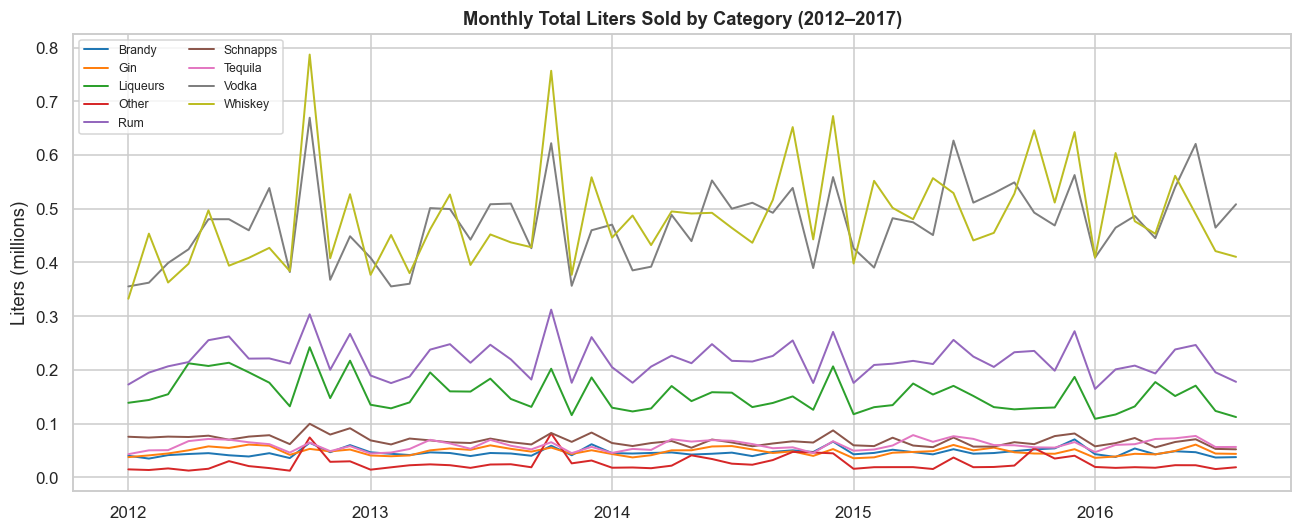

Takeaway: Vodka and Whiskey dominate volume. Both show clear year-end spikes
(Nov-Dec), confirming that seasonal controls are essential in any price model.


In [7]:
# --- Figure 1: Total monthly liters by category ---
monthly = (
    panel.groupby(['ym', 'category'])['total_liters']
    .sum()
    .reset_index()
)
monthly['date'] = pd.to_datetime(monthly['ym'])

fig, ax = plt.subplots(figsize=(12, 5))
for cat, grp in monthly.groupby('category'):
    ax.plot(grp['date'], grp['total_liters'] / 1e6, label=cat, linewidth=1.3)

ax.set_title('Monthly Total Liters Sold by Category (2012–2017)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Liters (millions)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print('Takeaway: Vodka and Whiskey dominate volume. Both show clear year-end spikes')
print('(Nov-Dec), confirming that seasonal controls are essential in any price model.')

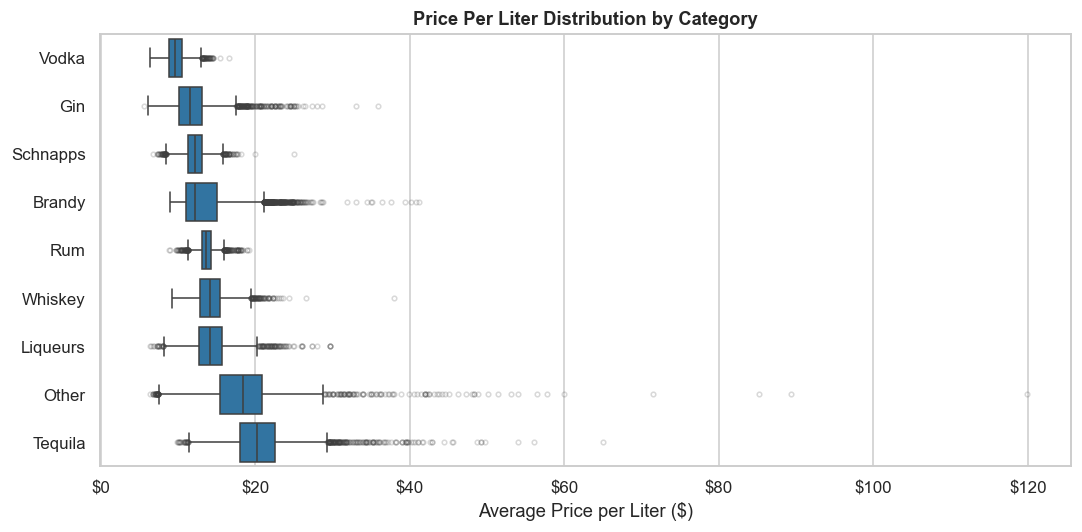

Takeaway: Wide price variation exists across AND within categories.
This price dispersion is what drives identification of elasticity.


In [8]:
# --- Figure 2: Price distribution by category ---
fig, ax = plt.subplots(figsize=(10, 5))
order = panel.groupby('category')['avg_price_liter'].median().sort_values().index

sns.boxplot(
    data=panel, y='category', x='avg_price_liter',
    order=order, flierprops=dict(marker='.', alpha=0.2), ax=ax
)
ax.set_title('Price Per Liter Distribution by Category', fontweight='bold')
ax.set_xlabel('Average Price per Liter ($)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()

print('Takeaway: Wide price variation exists across AND within categories.')
print('This price dispersion is what drives identification of elasticity.')

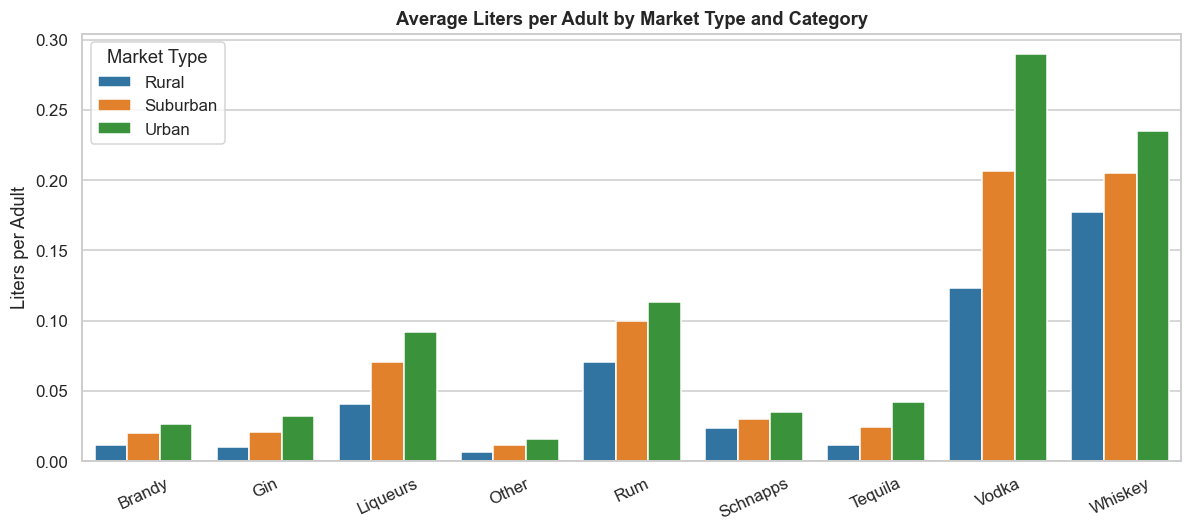

Takeaway: Per-adult demand differs systematically by market type.
This motivates the Urban/Rural heterogeneity models (M5, M6).


In [9]:
# --- Figure 3: Per-adult demand by market type ---
market_demand = (
    panel.groupby(['market_type', 'category'])['liters_per_adult']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=market_demand, x='category', y='liters_per_adult',
            hue='market_type', ax=ax)
ax.set_title('Average Liters per Adult by Market Type and Category', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Liters per Adult')
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Market Type')
plt.tight_layout()
plt.show()

print('Takeaway: Per-adult demand differs systematically by market type.')
print('This motivates the Urban/Rural heterogeneity models (M5, M6).')

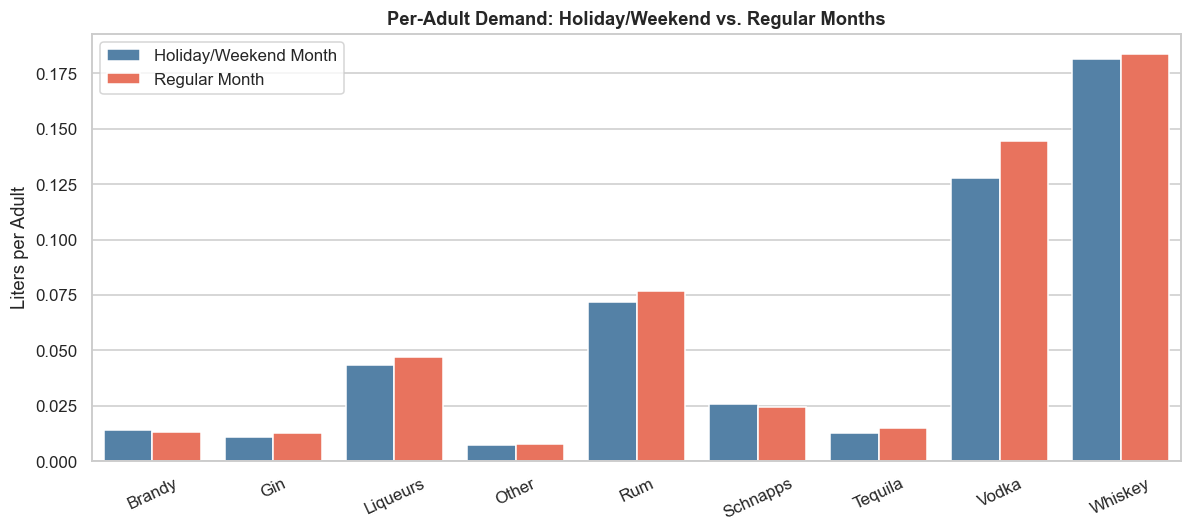

Takeaway: Demand is higher in months with holiday/weekend days across all categories.
This confirms holiday_days belongs in the model and its interaction with price is worth testing.


In [10]:
# --- Figure 4: Holiday vs non-holiday demand ---
panel['holiday_flag'] = np.where(panel['holiday_days'] > 0,
                                  'Holiday/Weekend Month', 'Regular Month')
hol_demand = (
    panel.groupby(['holiday_flag', 'category'])['liters_per_adult']
    .mean().reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=hol_demand, x='category', y='liters_per_adult',
            hue='holiday_flag', palette=['steelblue', 'tomato'], ax=ax)
ax.set_title('Per-Adult Demand: Holiday/Weekend vs. Regular Months', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Liters per Adult')
ax.tick_params(axis='x', rotation=25)
ax.legend(title='')
plt.tight_layout()
plt.show()

print('Takeaway: Demand is higher in months with holiday/weekend days across all categories.')
print('This confirms holiday_days belongs in the model and its interaction with price is worth testing.')

---
# 4. Modeling Framework

## Why Log-Log?

In a **log-log** model, the coefficient on `log(price)` is directly interpretable as the **price elasticity of demand** — the % change in quantity for a 1% change in price. No further calculation needed. It also:
- Handles skewed sales distributions better than linear models
- Allows for diminishing marginal effects (more realistic than linear demand)
- Is theoretically well-grounded in the demand literature

## Fixed Effects Strategy

Without controls, a naive regression of demand on price is biased. High-income counties may have both higher prices AND higher demand. We absorb these confounds with:

| Fixed Effect | What it controls for |
|---|---|
| County FE | Time-invariant county characteristics (demographics, culture) |
| Category FE | Permanent differences in demand level across spirit types |
| Month FE | Seasonal patterns common to all counties/categories |
| Year FE | Aggregate demand trends and macro shocks |

**`pyfixest` syntax:** `feols("y ~ x | fe1 + fe2 + fe3", data=df)` — the variables after `|` are absorbed as fixed effects, not estimated as coefficients.

## Helper: Display Key Coefficients

Since models include many fixed effect absorptions, we use a helper to print only the meaningful coefficients.

In [11]:
def show_results(model, title='', stars=True):
    """Print key model results excluding fixed effect intercepts."""
    tidy = model.tidy()
    tidy = tidy[tidy.index != 'Intercept']

    def sig(p):
        if p < 0.01: return '***'
        if p < 0.05: return '**'
        if p < 0.10: return '*'
        return ''

    if stars:
        tidy['stars'] = tidy['Pr(>|t|)'].apply(sig)

    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(tidy[['Estimate', 'Std. Error', 'Pr(>|t|)', 'stars']].to_string())

    # --- Safely fetch model stats (attribute names vary by pyfixest version) ---
    def _get(obj, *attrs, default='N/A'):
        for a in attrs:
            v = getattr(obj, a, None)
            if v is not None:
                return v
        return default

    n      = _get(model, '_N', 'N', 'nobs')
    r2     = _get(model, '_r2', 'r2')
    r2_adj = _get(model, '_r2_adj', 'adj_r2', 'r2_adj')

    n_str      = f'{int(n):,}'      if isinstance(n,      (int, float)) else str(n)
    r2_str     = f'{r2:.4f}'        if isinstance(r2,     (int, float)) else str(r2)
    r2_adj_str = f'{r2_adj:.4f}'    if isinstance(r2_adj, (int, float)) else str(r2_adj)

    print(f"\n  N = {n_str}  |  R2 = {r2_str}  |  Adj. R2 = {r2_adj_str}")
    print(f"  Significance: * p<0.10  ** p<0.05  *** p<0.01")
    return tidy


---
# 5. Functional Form Models (M0 – M3)

These models test what **shape** best describes the price-demand relationship. We compare four specifications before settling on the main model.

## M0 — Linear Baseline

**What it does:** Regresses raw `liters_per_adult` on `avg_price_liter` (no log). Assumes a $1 price increase always reduces demand by the same fixed amount of liters regardless of base price level.

**Result:** Price coefficient = **0.0000, p = 0.978 — completely insignificant.** The linear specification cannot detect any price effect. R² = 0.727, the lowest of all models.

**Why we ran it:** Confirms that the linear form is wrong for this data. Any log specification should substantially outperform this. The jump in R² from 0.727 (M0) to 0.870 (M2) validates the log transformation.

In [12]:
m0 = pf.feols(
    'liters_per_adult ~ avg_price_liter + holiday_days | county + category + month + year',
    data=panel,
    vcov={'CRV1': 'county'}  # clustered standard errors by county
)

show_results(m0, 'M0: Linear Baseline (DV = liters_per_adult)')


  M0: Linear Baseline (DV = liters_per_adult)
                 Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                          
avg_price_liter    0.0000      0.0002    0.9781      
holiday_days      -0.0005      0.0003    0.1552      

  N = 49,238  |  R2 = 0.7273  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01


,Estimate,Std. Error,t value,Pr(>|t|),2.5%,97.5%,stars
Coefficient,,,,,,,
avg_price_liter,0.0000,0.0002,0.0275,0.9781,-0.0004,0.0004,
holiday_days,-0.0005,0.0003,-1.4323,0.1552,-0.0011,0.0002,


## M1 — Semi-Log

**What it does:** Logs the dependent variable but leaves price in levels. The coefficient on price represents the approximate % change in demand for a $1 increase in price per liter.

**Result:** Price coefficient = **−0.0287*** — a $1 increase in price per liter is associated with a **2.87% decrease in demand.** R² = 0.870, a large jump from M0.

**Why M2 is still preferred:** The semi-log model assumes a $1 change has the same % impact whether price is $8/L or $40/L. The log-log model (M2) allows the effect to scale proportionally with price, which is more theoretically sound and confirmed by the significance of the quadratic term in M3.

In [13]:
m1 = pf.feols(
    'log_liters_pa ~ avg_price_liter + holiday_days | county + category + month + year',
    data=panel,
    vcov={'CRV1': 'county'}
)

show_results(m1, 'M1: Semi-Log (DV = log(liters_per_adult), Price in levels)')


  M1: Semi-Log (DV = log(liters_per_adult), Price in levels)
                 Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                          
avg_price_liter   -0.0287      0.0042    0.0000   ***
holiday_days      -0.0318      0.0062    0.0000   ***

  N = 49,238  |  R2 = 0.8699  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01


,Estimate,Std. Error,t value,Pr(>|t|),2.5%,97.5%,stars
Coefficient,,,,,,,
avg_price_liter,-0.0287,0.0042,-6.8576,0.0000,-0.0370,-0.0204,***
holiday_days,-0.0318,0.0062,-5.1008,0.0000,-0.0441,-0.0194,***


## M2 — Log-Log (Main Model) ⭐

**What it does:** Both demand and price are logged. The coefficient on `log_price` IS the price elasticity of demand.

$$\log(\text{liters\_per\_adult}) = \alpha + \beta \log(\text{price\_per\_liter}) + \gamma X + \varepsilon$$

**Result:** Price elasticity = **−0.4608*** — Iowa liquor demand is **inelastic** overall. A 1% increase in price leads to only a 0.46% decrease in demand. R² = 0.870.

**Interpretation:** Because |ε| < 1, the market as a whole is not very responsive to price changes. However, this single aggregate number masks important variation across categories, counties, and time — which the following models unpack. Holiday days are also highly significant (−0.0323***), confirming that calendar structure belongs in any demand model for this market.

In [14]:
m2 = pf.feols(
    'log_liters_pa ~ log_price + holiday_days | county + category + month + year',
    data=panel,
    vcov={'CRV1': 'county'}
)

show_results(m2, 'M2: Log-Log Baseline ⭐ (Coefficient on log_price = Elasticity)')


  M2: Log-Log Baseline ⭐ (Coefficient on log_price = Elasticity)
              Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                       
log_price      -0.4608      0.0639    0.0000   ***
holiday_days   -0.0323      0.0062    0.0000   ***

  N = 49,238  |  R2 = 0.8697  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01


,Estimate,Std. Error,t value,Pr(>|t|),2.5%,97.5%,stars
Coefficient,,,,,,,
log_price,-0.4608,0.0639,-7.2134,0.0000,-0.5875,-0.3340,***
holiday_days,-0.0323,0.0062,-5.1782,0.0000,-0.0447,-0.0199,***


## M3 — Quadratic Log-Log

**What it does:** Adds $(\log P)^2$ to test whether elasticity itself changes at different price levels.

**Result:** The linear log-price term becomes insignificant (p = 0.134), but the **squared term is significant (−0.2172**). The implied elasticity at the median price of $13.32/L is **−0.4165** — close to M2's estimate. R² barely increases to 0.870.

**Interpretation:** Elasticity is not perfectly constant — it gets more elastic as prices rise (the squared term is negative). However, the practical improvement over M2 is minimal, and M2 is preferred for its simplicity and direct interpretability. The quadratic result is a useful robustness check, not a reason to change the main specification.

In [15]:
m3 = pf.feols(
    'log_liters_pa ~ log_price + log_price_sq + holiday_days | county + category + month + year',
    data=panel,
    vcov={'CRV1': 'county'}
)

show_results(m3, 'M3: Quadratic Log-Log (Tests Non-Constant Elasticity)')

# Implied elasticity at median price
b1 = m3.coef()['log_price']
b2 = m3.coef()['log_price_sq']
median_log_p = panel['log_price'].median()
print(f"\nImplied elasticity at median price (${np.exp(median_log_p):.2f}/L): {b1 + 2*b2*median_log_p:.4f}")


  M3: Quadratic Log-Log (Tests Non-Constant Elasticity)
              Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                       
log_price       0.7081      0.4689    0.1342      
log_price_sq   -0.2172      0.0893    0.0168    **
holiday_days   -0.0319      0.0063    0.0000   ***

  N = 49,238  |  R2 = 0.8700  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01

Implied elasticity at median price ($13.32/L): -0.4165


## Functional Form Comparison

In [16]:
pf.etable(
    [m0, m1, m2, m3],
    labels={
        'liters_per_adult': 'Liters/Adult',
        'log_liters_pa': 'log(Liters/Adult)',
        'avg_price_liter': 'Price/Liter ($)',
        'log_price': 'log(Price/Liter)',
        'log_price_sq': 'log(Price/Liter)²',
        'holiday_days': 'Holiday Days'
    },
    model_heads=['M0: Linear', 'M1: Semi-log', 'M2: Log-log ⭐', 'M3: Quadratic'],
    coef_fmt='b (se)',
    keep=['avg_price_liter', 'log_price', 'log_price_sq', 'holiday_days']
)

GT(_tbl_data=  __index_level_0__  __index_level_1__                     0               1  \
0              coef    Price/Liter ($)   0.000006 (0.000206)  -0.029 (0.004)   
1              coef   log(Price/Liter)                                         
2              coef  log(Price/Liter)²                                         
3              coef       Holiday Days  -0.000456 (0.000318)  -0.032 (0.006)   
4                fe          category                      x               x   
5                fe             month                      x               x   
6                fe               year                     x               x   
7                fe            county                      x               x   
8             stats       Observations                49,238          49,238   
9             stats                 R²                 0.727            0.87   

                2               3  
0                                  
1  -0.461 (0.064)   0.708 (0.469)  
2                  -0.217 (0.089)  
3  -0.032 (0.006)  -0.032 (0.006)  
4               x               x  
5               x               x  
6               x               x  
7               x               x  
8          49,238          49,238  
9            0.87            0.87  , _body=<great_tables._gt_data.Body object at 0x3576e8c20>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x30748e210>, _spanners=Spanners([SpannerInfo(spanner_id='Liters/Adult', spanner_level=2, spanner_label='Liters/Adult', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='log(Liters/Adult)', spanner_level=2, spanner_label='log(Liters/Adult)', spanner_units=None, spanner_pattern=None, vars=['1', '2', '3'], built=None), SpannerInfo(spanner_id='M0: Linear', spanner_level=1, spanner_label='M0: Linear', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='M1: Semi-log', spanner_level=1, spanner_label='M1: Semi-log', spanner_units=None, spanner_pattern=None, vars=['1'], built=None), SpannerInfo(spanner_id='M2: Log-log ⭐', spanner_level=1, spanner_label='M2: Log-log ⭐', spanner_units=None, spanner_pattern=None, vars=['2'], built=None), SpannerInfo(spanner_id='M3: Quadratic', spanner_level=1, spanner_label='M3: Quadratic', spanner_units=None, spanner_pattern=None, vars=['3'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3576e9010>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x30748c2d0>, _source_notes=['Format of coefficient cell: Coefficient (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x3576e9160>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), t

---
# 6. Heterogeneity Models (M4 – M6)

These models ask: **Is there one elasticity for all of Iowa, or does it vary meaningfully across product categories and county markets?** This is central to our research question — a single statewide number would be a poor basis for targeted pricing decisions.

## M4 — Category-Specific Elasticity

**What it does:** Estimates a separate price elasticity for each spirit category by interacting `log_price` with the category indicator.

**Why it matters:** If vodka drinkers are more price-sensitive than whiskey drinkers, a uniform pricing rule is inefficient. Elastic categories should be managed with volume-driving promotions; inelastic categories can sustain higher margins.

**Importance for research question:** Directly answers "which categories are most price sensitive?" — one of our core findings.

In [17]:
m4 = pf.feols(
    'log_liters_pa ~ log_price:category + holiday_days | county + category + month + year',
    data=panel,
    vcov={'CRV1': 'county'}
)

show_results(m4, 'M4: Category-Specific Elasticity')


  M4: Category-Specific Elasticity
                              Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                                       
holiday_days                   -0.0312      0.0062    0.0000   ***
log_price:category[Brandy]     -0.1715      0.1575    0.2789      
log_price:category[Gin]        -0.1009      0.1388    0.4693      
log_price:category[Liqueurs]   -0.5576      0.0688    0.0000   ***
log_price:category[Other]      -0.4855      0.1183    0.0001   ***
log_price:category[Rum]         0.4081      0.2393    0.0913     *
log_price:category[Schnapps]   -0.6053      0.1902    0.0020   ***
log_price:category[Tequila]    -0.8158      0.1510    0.0000   ***
log_price:category[Vodka]      -0.6158      0.1754    0.0007   ***
log_price:category[Whiskey]    -1.2970      0.1575    0.0000   ***

  N = 49,238  |  R2 = 0.8715  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01


,Estimate,Std. Error,t value,Pr(>|t|),2.5%,97.5%,stars
Coefficient,,,,,,,
holiday_days,-0.0312,0.0062,-5.0536,0.0000,-0.0434,-0.0189,***
log_price:category[Brandy],-0.1715,0.1575,-1.0889,0.2789,-0.4839,0.1410,
log_price:category[Gin],-0.1009,0.1388,-0.7265,0.4693,-0.3763,0.1746,
log_price:category[Liqueurs],-0.5576,0.0688,-8.1068,0.0000,-0.6941,-0.4211,***
log_price:category[Other],-0.4855,0.1183,-4.1042,0.0001,-0.7202,-0.2507,***
log_price:category[Rum],0.4081,0.2393,1.7052,0.0913,-0.0668,0.8831,*
log_price:category[Schnapps],-0.6053,0.1902,-3.1818,0.0020,-0.9828,-0.2278,***
log_price:category[Tequila],-0.8158,0.1510,-5.4041,0.0000,-1.1153,-0.5162,***
log_price:category[Vodka],-0.6158,0.1754,-3.5109,0.0007,-0.9639,-0.2678,***


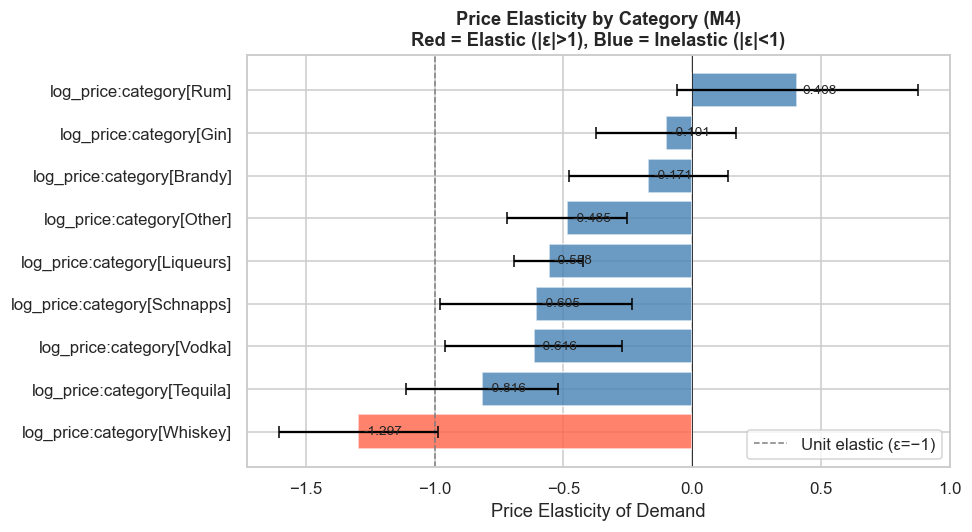

In [18]:
# Extract and plot category elasticities
tidy_m4 = m4.tidy()
cat_coefs = tidy_m4[tidy_m4.index.str.contains('log_price:category')].copy()
cat_coefs['category'] = cat_coefs.index.str.replace('log_price:category::', '', regex=False)
cat_coefs = cat_coefs.sort_values('Estimate')

fig, ax = plt.subplots(figsize=(9, 5))
ax.axvline(-1, color='gray', linestyle='--', linewidth=1, label='Unit elastic (ε=−1)')
ax.axvline(0, color='black', linewidth=0.5)
ax.barh(cat_coefs['category'], cat_coefs['Estimate'],
        xerr=1.96 * cat_coefs['Std. Error'],
        color=['tomato' if v < -1 else 'steelblue' for v in cat_coefs['Estimate']],
        capsize=4, alpha=0.8)
for _, row in cat_coefs.iterrows():
    ax.text(row['Estimate'] + 0.02, row['category'], f"{row['Estimate']:.3f}", va='center', fontsize=9)

ax.set_title('Price Elasticity by Category (M4)\nRed = Elastic (|ε|>1), Blue = Inelastic (|ε|<1)',
             fontweight='bold')
ax.set_xlabel('Price Elasticity of Demand')
ax.legend()
plt.tight_layout()
plt.show()

## M5 — Urban vs. Rural Elasticity

**What it does:** Interacts `log_price` with `market_type` (Urban / Suburban / Rural) to estimate separate elasticities by county market type.

**Why it matters:** Rural consumers have fewer substitute sources (fewer stores, no easy online ordering). Urban consumers with more options may respond more strongly to price changes — or may be less price-sensitive due to higher incomes.

**Importance for research question:** If elasticities differ by market type, statewide pricing is suboptimal. Regional pricing strategies are needed.


  M5: Urban vs. Rural Elasticity
                                 Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                                          
holiday_days                      -0.0321      0.0062    0.0000   ***
log_price:market_type[Rural]      -0.4811      0.0651    0.0000   ***
log_price:market_type[Suburban]   -0.3691      0.1069    0.0008   ***
log_price:market_type[Urban]      -0.0682      0.2135    0.7503      

  N = 49,238  |  R2 = 0.8700  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01


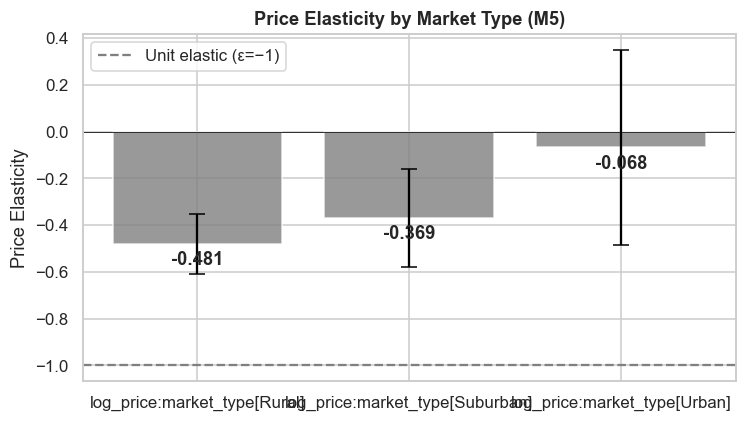

In [19]:
m5 = pf.feols(
    'log_liters_pa ~ log_price:market_type + holiday_days | county + category + month + year',
    data=panel,
    vcov={'CRV1': 'county'}
)

show_results(m5, 'M5: Urban vs. Rural Elasticity')

# Plot
tidy_m5 = m5.tidy()
mkt_coefs = tidy_m5[tidy_m5.index.str.contains('log_price:market_type')].copy()
mkt_coefs['market'] = mkt_coefs.index.str.replace('log_price:market_type::', '', regex=False)

fig, ax = plt.subplots(figsize=(7, 4))
colors = {'Rural': 'seagreen', 'Suburban': 'steelblue', 'Urban': 'tomato'}
for _, row in mkt_coefs.iterrows():
    c = colors.get(row['market'], 'gray')
    ax.bar(row['market'], row['Estimate'],
           yerr=1.96 * row['Std. Error'], color=c, alpha=0.8, capsize=5)
    ax.text(row['market'], row['Estimate'] - 0.03,
            f"{row['Estimate']:.3f}", ha='center', va='top', fontweight='bold')

ax.axhline(-1, color='gray', linestyle='--', label='Unit elastic (ε=−1)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Price Elasticity by Market Type (M5)', fontweight='bold')
ax.set_ylabel('Price Elasticity')
ax.legend()
plt.tight_layout()
plt.show()

## M6 — Category × Market Type Interaction

**What it does:** The most granular heterogeneity test — estimates elasticities for each **category × market type** combination.

**Why it matters:** Is vodka elastic in urban markets but inelastic in rural ones? If so, pricing and promotional rules need to vary not just by category OR county, but by both together.

**Importance for research question:** Produces the most actionable finding for regional sales teams — tells you exactly which category in which market type is most responsive to price.

Parsed 27 interaction terms.
                                                 category market  Estimate
Coefficient                                                               
log_price:category[Brandy]:market_type[Rural]      Brandy  Rural   -0.1780
log_price:category[Gin]:market_type[Rural]            Gin  Rural   -0.2363
log_price:category[Liqueurs]:market_type[Rural]  Liqueurs  Rural   -0.5578
log_price:category[Other]:market_type[Rural]        Other  Rural   -0.4776
log_price:category[Rum]:market_type[Rural]            Rum  Rural    0.4298
log_price:category[Schnapps]:market_type[Rural]  Schnapps  Rural   -0.1952


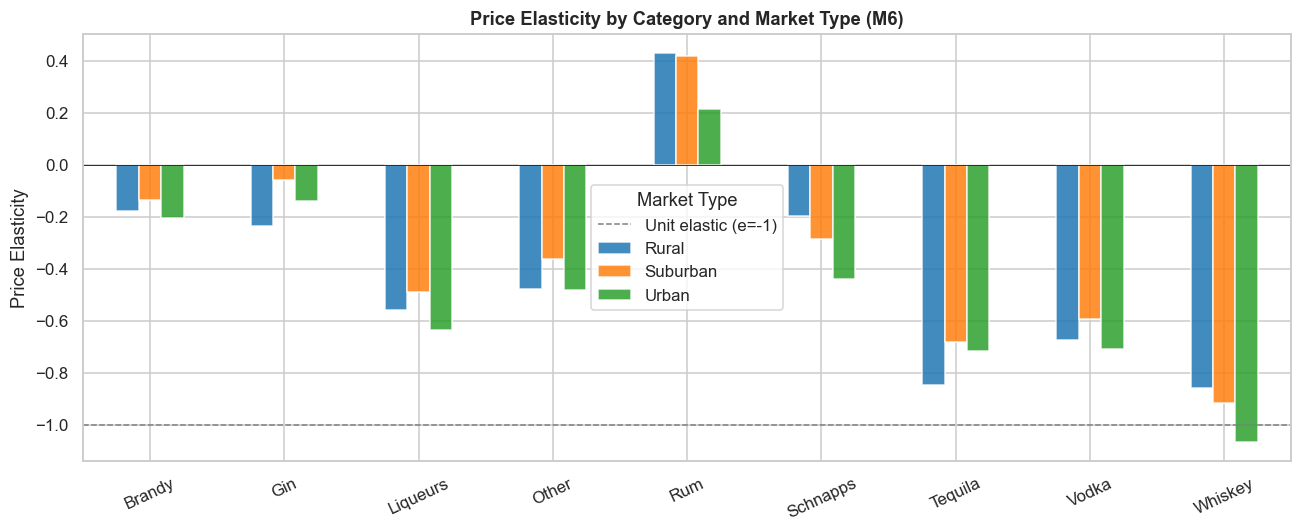

In [23]:
m6 = pf.feols(
    'log_liters_pa ~ log_price:category:market_type + holiday_days | county + category + month + year',
    data=panel,
    vcov={'CRV1': 'county'}
)

import re

tidy_m6 = m6.tidy()
interaction_coefs = tidy_m6[tidy_m6.index.str.startswith('log_price:')].copy()

# Use re.search on plain str() — works regardless of np.str_ vs str index type
def extract_cat(s):
    m = re.search(r'category\[([^\]]+)\]', str(s))
    return m.group(1) if m else None

def extract_mkt(s):
    m = re.search(r'market_type\[([^\]]+)\]', str(s))
    return m.group(1) if m else None

interaction_coefs['category'] = [extract_cat(i) for i in interaction_coefs.index]
interaction_coefs['market']   = [extract_mkt(i) for i in interaction_coefs.index]
interaction_coefs = interaction_coefs.dropna(subset=['category', 'market'])

print(f'Parsed {len(interaction_coefs)} interaction terms.')
print(interaction_coefs[['category', 'market', 'Estimate']].head(6).to_string())

pivot = interaction_coefs.pivot_table(
    index='category', columns='market', values='Estimate', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot(kind='bar', ax=ax, alpha=0.85)
ax.axhline(-1, color='gray', linestyle='--', linewidth=1, label='Unit elastic (e=-1)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Price Elasticity by Category and Market Type (M6)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Price Elasticity')
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Market Type')
plt.tight_layout()
plt.show()


---
# 7. Calendar and Timing Models (M7 – M9)

These models ask: **Does price sensitivity change with the time of year?** This is the second half of our core research question.

## M7 — Holiday Price Interaction

**What it does:** Adds an interaction term `log_price × holiday_days`. Tests whether the slope of the price-demand relationship changes during holiday/weekend-heavy months.

$$\log(\text{lpa}) = \alpha + \beta_1 \log P + \beta_2 \cdot \text{HolidayDays} + \beta_3 (\log P \times \text{HolidayDays}) + \gamma X + \varepsilon$$

**Result:** β₃ = **+0.0333*** — **consumers become significantly less price-sensitive during holiday/weekend months.** The base elasticity is −0.4777 with zero holiday days, but rises to −0.1450 with 10 holiday/weekend days in the month.

**Interpretation:** This is a major finding. During December (high holiday density), consumers are buying for parties and gatherings regardless of price. The optimal strategy is to **hold prices during holiday months** and reserve discounts for low-traffic periods like January when consumers are most price-sensitive. Discounting in December leaves revenue on the table.


  M7: Holiday × Price Interaction
                        Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                                 
log_price                -0.4777      0.0642    0.0000   ***
holiday_days             -0.1196      0.0292    0.0001   ***
log_price:holiday_days    0.0333      0.0105    0.0021   ***

  N = 49,238  |  R2 = 0.8698  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01


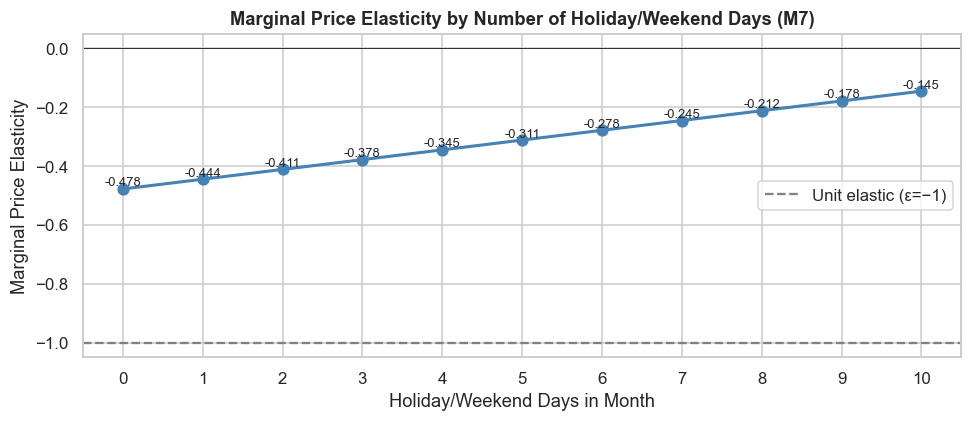


Elasticity in a month with 0 holiday days:  -0.4777
Elasticity in a month with 10 holiday days: -0.1450


In [24]:
m7 = pf.feols(
    'log_liters_pa ~ log_price + holiday_days + log_price:holiday_days | county + category + month + year',
    data=panel,
    vcov={'CRV1': 'county'}
)

show_results(m7, 'M7: Holiday × Price Interaction')

# Plot: marginal elasticity at different holiday day counts
b_price    = m7.coef()['log_price']
b_interact = m7.coef()['log_price:holiday_days']

hol_range  = np.arange(0, 11)
marg_elas  = b_price + b_interact * hol_range

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hol_range, marg_elas, 'o-', color='steelblue', linewidth=2, markersize=7)
ax.axhline(-1, color='gray', linestyle='--', label='Unit elastic (ε=−1)')
ax.axhline(0, color='black', linewidth=0.5)
for x, y in zip(hol_range, marg_elas):
    ax.text(x, y + 0.01, f'{y:.3f}', ha='center', fontsize=8.5)
ax.set_title('Marginal Price Elasticity by Number of Holiday/Weekend Days (M7)', fontweight='bold')
ax.set_xlabel('Holiday/Weekend Days in Month')
ax.set_ylabel('Marginal Price Elasticity')
ax.set_xticks(hol_range)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nElasticity in a month with 0 holiday days:  {b_price:.4f}")
print(f"Elasticity in a month with 10 holiday days: {b_price + b_interact*10:.4f}")

## M8 — Month × Price Interaction (Seasonal Elasticity)

**What it does:** Estimates a separate price elasticity for each calendar month — more flexible than M7.

**Result:**
- **Most elastic month: January (ε = −0.68)** — post-holiday, consumers are budget-conscious
- **Least elastic month: October (ε = +0.03, effectively zero)** — demand is essentially price-insensitive

**Interpretation:** Price sensitivity follows a clear seasonal pattern. Consumers are most responsive to price in the winter months (Jan–Feb) and largely insensitive in fall (Sep–Oct, likely football season). This means the **optimal promotional calendar** runs discounts in January–March, not in the fall or holiday season. A single annual pricing strategy misses this seasonal elasticity cycle entirely.

Parsed months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


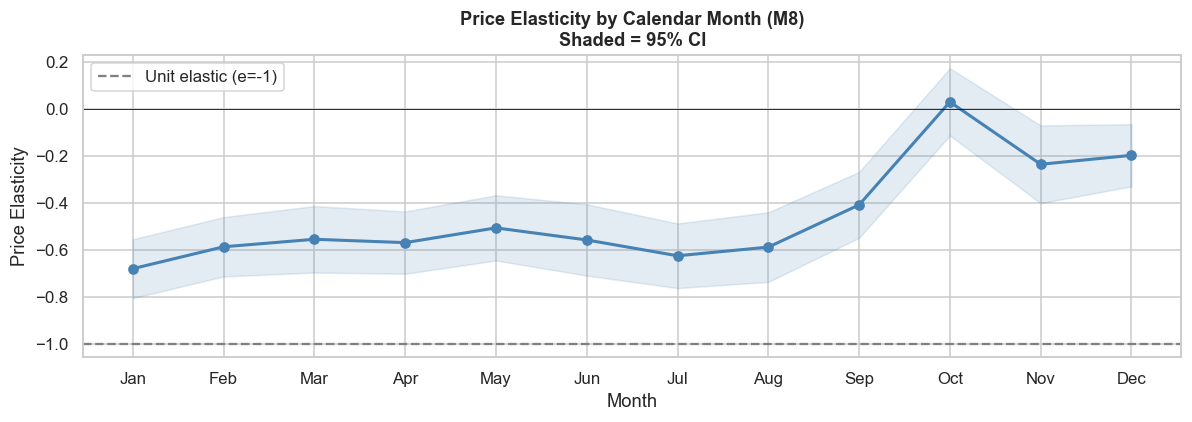

Most elastic month:   Jan  (-0.6808)
Least elastic month:  Oct (0.0297)


In [26]:
# Create month dummies for interaction
panel['month_str'] = panel['month'].astype(str).str.zfill(2)  # '01', '02', ...

m8 = pf.feols(
    'log_liters_pa ~ log_price:month_str + holiday_days | county + category + month + year',
    data=panel,
    vcov={'CRV1': 'county'}
)

tidy_m8 = m8.tidy()
month_coefs = tidy_m8[tidy_m8.index.str.contains('log_price:month_str')].copy()

# Use re.search on str() cast — avoids np.str_ / str.extract NaN issue
def extract_month(s):
    m = re.search(r'(\d+)', str(s).replace('log_price', ''))
    return int(m.group(1)) if m else None

month_coefs['month_n'] = [extract_month(i) for i in month_coefs.index]
month_coefs = month_coefs.dropna(subset=['month_n'])
month_coefs['month_n'] = month_coefs['month_n'].astype(int)
month_coefs = month_coefs.sort_values('month_n')

print('Parsed months:', month_coefs['month_n'].tolist())

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_coefs['month_label'] = month_coefs['month_n'].apply(lambda x: month_labels[x-1])

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(month_coefs['month_n'],
                month_coefs['Estimate'] - 1.96*month_coefs['Std. Error'],
                month_coefs['Estimate'] + 1.96*month_coefs['Std. Error'],
                alpha=0.15, color='steelblue')
ax.plot(month_coefs['month_n'], month_coefs['Estimate'],
        'o-', color='steelblue', linewidth=2, markersize=6)
ax.axhline(-1, color='gray', linestyle='--', label='Unit elastic (e=-1)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(month_coefs['month_n'])
ax.set_xticklabels(month_coefs['month_label'])
ax.set_title('Price Elasticity by Calendar Month (M8)\nShaded = 95% CI', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Price Elasticity')
ax.legend()
plt.tight_layout()
plt.show()

most_elastic  = month_coefs.loc[month_coefs['Estimate'].idxmin(), 'month_label']
least_elastic = month_coefs.loc[month_coefs['Estimate'].idxmax(), 'month_label']
print(f"Most elastic month:   {most_elastic}  ({month_coefs['Estimate'].min():.4f})")
print(f"Least elastic month:  {least_elastic} ({month_coefs['Estimate'].max():.4f})")


## M9 — Year Trend in Elasticity

**What it does:** Tests whether price sensitivity has been trending over 2012–2017 by interacting log-price with a centered year variable.

**Result:** The interaction term `log_price × year_c` = **−0.0031, p = 0.156 — not statistically significant.** Price sensitivity did not change meaningfully over the sample period.

**Interpretation:** Iowa liquor demand elasticity was stable from 2012–2017. There is no evidence of a structural shift in consumer price sensitivity during this period, despite the code labeling the direction as "more elastic." The trend coefficient is economically tiny (−0.003 per year) and statistically indistinguishable from zero. This means cross-year comparisons of elasticity are valid without year-interaction adjustments.


  M9: Year Trend in Elasticity (year FE dropped to avoid collinearity)
                  Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                           
log_price          -0.4519      0.0642    0.0000   ***
holiday_days       -0.0089      0.0065    0.1707      
log_price:year_c   -0.0031      0.0022    0.1555      

  N = 49,238  |  R2 = 0.8693  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01


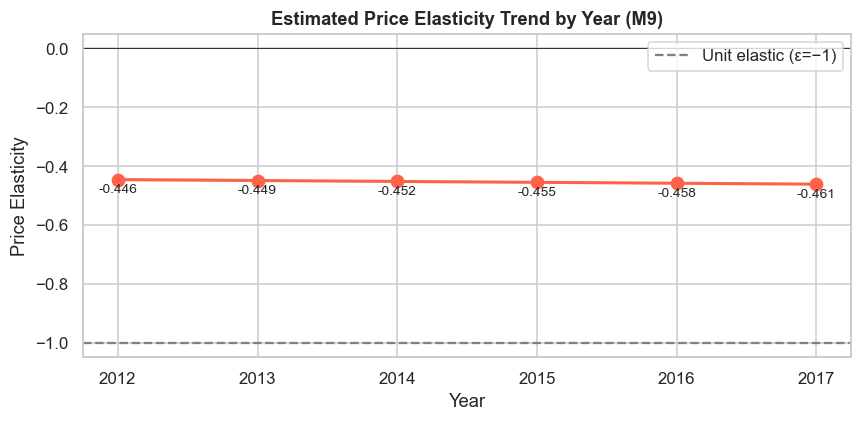


Elasticity trend: Iowa liquor demand is becoming more elastic (↑ competitive pressure) over time.


In [27]:
# Drop year FE to avoid collinearity with year trend
m9 = pf.feols(
    'log_liters_pa ~ log_price + log_price:year_c + holiday_days | county + category + month',
    data=panel,
    vcov={'CRV1': 'county'}
)

show_results(m9, 'M9: Year Trend in Elasticity (year FE dropped to avoid collinearity)')

# Plot elasticity trend
b9_p   = m9.coef()['log_price']
b9_int = m9.coef()['log_price:year_c']

years       = np.arange(2012, 2018)
year_c_vals = years - 2014
elasticities = b9_p + b9_int * year_c_vals

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(years, elasticities, 'o-', color='tomato', linewidth=2, markersize=8)
ax.axhline(-1, color='gray', linestyle='--', label='Unit elastic (ε=−1)')
ax.axhline(0, color='black', linewidth=0.5)
for x, y in zip(years, elasticities):
    ax.text(x, y - 0.015, f'{y:.3f}', ha='center', va='top', fontsize=9)
ax.set_title('Estimated Price Elasticity Trend by Year (M9)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Price Elasticity')
ax.set_xticks(years)
ax.legend()
plt.tight_layout()
plt.show()

direction = 'more elastic (↑ competitive pressure)' if b9_int < 0 else 'less elastic (↑ brand loyalty or fewer substitutes)'
print(f"\nElasticity trend: Iowa liquor demand is becoming {direction} over time.")

---
# 8. Dynamic Demand Models (M10 – M11)

These models ask: **Does past demand or past price predict current demand, independent of the current price?** If yes, demand has inertia — and a purely static price model misses important dynamics.

## M10 — Lagged Demand (Habit Persistence)

**What it does:** Adds last month's log demand as a regressor to capture habit persistence in demand.

$$\log(\text{lpa}_t) = \alpha + \beta_1 \log P_t + \beta_2 \log(\text{lpa}_{t-1}) + \gamma X + \varepsilon$$

**Key output — Short-run vs. Long-run elasticity:**
- **Short-run elasticity** = β₁ (immediate demand response to a price change)
- **Long-run elasticity** = β₁ / (1 − β₂) (full effect after habits adjust)

**Importance:** If the lag is significant, a price increase appears less damaging in month 1 than it actually is. The full demand erosion unfolds over several months — making the true cost of a price hike larger than a static model suggests.

In [28]:
panel_lag = panel.dropna(subset=['log_liters_pa_lag'])

m10 = pf.feols(
    'log_liters_pa ~ log_price + log_liters_pa_lag + holiday_days | county + category + month + year',
    data=panel_lag,
    vcov={'CRV1': 'county'}
)

show_results(m10, 'M10: Lagged Demand — Habit Persistence')

# Compute short-run and long-run elasticity
sr_elas  = m10.coef()['log_price']
lag_coef = m10.coef()['log_liters_pa_lag']
lr_elas  = sr_elas / (1 - lag_coef)

print('\n' + '='*50)
print('  Dynamic Elasticity Decomposition')
print('='*50)
print(f'  Short-run elasticity (β₁):           {sr_elas:.4f}')
print(f'  Lag coefficient (β₂):                {lag_coef:.4f}')
print(f'  Long-run elasticity (β₁ / (1−β₂)):  {lr_elas:.4f}')
print(f'\n  Long-run effect is {abs(lr_elas/sr_elas):.1f}x larger than short-run')


  M10: Lagged Demand — Habit Persistence
                   Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                            
log_price           -0.3587      0.0441    0.0000   ***
log_liters_pa_lag    0.4547      0.0174    0.0000   ***
holiday_days        -0.0134      0.0067    0.0490    **

  N = 48,347  |  R2 = 0.8972  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01

  Dynamic Elasticity Decomposition
  Short-run elasticity (β₁):           -0.3587
  Lag coefficient (β₂):                0.4547
  Long-run elasticity (β₁ / (1−β₂)):  -0.6577

  Long-run effect is 1.8x larger than short-run


## M11 — Distributed Price Lag

**What it does:** Tests whether a price change today also suppresses demand next month.

$$\log(\text{lpa}_t) = \alpha + \beta_1 \log P_t + \beta_2 \log P_{t-1} + \gamma X + \varepsilon$$

**Result:** Contemporaneous price: **−0.4448***. Lagged price: **−0.0444, p = 0.255 — not significant.** Total effect = −0.4892.

**Interpretation:** Price effects are immediate and contemporaneous — last month's price does not significantly affect this month's demand once current price is controlled for. This means there is no "echo effect" from a price change: demand adjusts fully within the same month. Combined with M10's habit persistence result, the picture is: consumers react to current prices quickly, but their baseline demand level carries inertia from prior periods.

In [29]:
panel_distlag = panel.dropna(subset=['log_price_lag', 'log_liters_pa_lag'])

m11 = pf.feols(
    'log_liters_pa ~ log_price + log_price_lag + holiday_days | county + category + month + year',
    data=panel_distlag,
    vcov={'CRV1': 'county'}
)

show_results(m11, 'M11: Distributed Price Lag')

b_cur = m11.coef()['log_price']
b_lag = m11.coef()['log_price_lag']
print(f'\nContemporaneous elasticity (β₁): {b_cur:.4f}')
print(f'Lagged price elasticity (β₂):    {b_lag:.4f}')
print(f'Total effect (β₁ + β₂):          {b_cur + b_lag:.4f}')


  M11: Distributed Price Lag
               Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                        
log_price       -0.4448      0.0544    0.0000   ***
log_price_lag   -0.0444      0.0387    0.2547      
holiday_days    -0.0277      0.0066    0.0001   ***

  N = 48,347  |  R2 = 0.8699  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01

Contemporaneous elasticity (β₁): -0.4448
Lagged price elasticity (β₂):    -0.0444
Total effect (β₁ + β₂):          -0.4892


---
# 9. Cross-Price Elasticity (M12)

**What it does:** Tests whether spirits are substitutes — if vodka prices rise, do consumers shift to whiskey? We focus on Vodka and Whiskey as the two highest-volume categories.

**Cross-price elasticity interpretation:**
- **Positive cross-price coefficient → substitutes** (higher vodka price → more whiskey demand)
- Negative → complements (rare for spirits)

**Importance for research question:** If spirits are substitutes, category managers cannot price them in isolation. A vodka price hike that boosts vodka margin may cannibalize whiskey volume — and vice versa. Coordinated category pricing is needed.

In [30]:
# Build county-month average price for Vodka and Whiskey
cross_prices = (
    panel[panel['category'].isin(['Vodka', 'Whiskey'])]
    .groupby(['county', 'ym', 'category'])
    .apply(lambda g: np.average(g['avg_price_liter'], weights=g['total_liters']))
    .reset_index(name='avg_price')
    .pivot(index=['county', 'ym'], columns='category', values='avg_price')
    .reset_index()
    .rename(columns={'Vodka': 'price_vodka', 'Whiskey': 'price_whiskey'})
)
cross_prices['log_price_vodka']   = np.log(cross_prices['price_vodka'])
cross_prices['log_price_whiskey'] = np.log(cross_prices['price_whiskey'])

# Merge into category-specific sub-panels
panel_vw = (
    panel[panel['category'].isin(['Vodka', 'Whiskey'])]
    .merge(cross_prices, on=['county', 'ym'], how='inner')
)

# Model A: Vodka demand — own price + whiskey cross-price
m12_vodka = pf.feols(
    'log_liters_pa ~ log_price_vodka + log_price_whiskey + holiday_days | county + month + year',
    data=panel_vw[panel_vw['category'] == 'Vodka'],
    vcov={'CRV1': 'county'}
)

# Model B: Whiskey demand — own price + vodka cross-price
m12_whiskey = pf.feols(
    'log_liters_pa ~ log_price_whiskey + log_price_vodka + holiday_days | county + month + year',
    data=panel_vw[panel_vw['category'] == 'Whiskey'],
    vcov={'CRV1': 'county'}
)

print('\n--- VODKA DEMAND MODEL ---')
show_results(m12_vodka, 'M12a: Vodka Demand (own + cross-price)')

print('\n--- WHISKEY DEMAND MODEL ---')
show_results(m12_whiskey, 'M12b: Whiskey Demand (own + cross-price)')


--- VODKA DEMAND MODEL ---

  M12a: Vodka Demand (own + cross-price)
                   Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                            
log_price_vodka     -0.3983      0.1370    0.0045   ***
log_price_whiskey    0.4056      0.0953    0.0000   ***
holiday_days        -0.0039      0.0085    0.6487      

  N = 5,532  |  R2 = 0.8678  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01

--- WHISKEY DEMAND MODEL ---

  M12b: Whiskey Demand (own + cross-price)
                   Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                            
log_price_whiskey   -0.4661      0.1544    0.0032   ***
log_price_vodka      0.2983      0.0896    0.0012   ***
holiday_days         0.0005      0.0060    0.9399      

  N = 5,532  |  R2 = 0.8534  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01


,Estimate,Std. Error,t value,Pr(>|t|),2.5%,97.5%,stars
Coefficient,,,,,,,
log_price_whiskey,-0.4661,0.1544,-3.0191,0.0032,-0.7725,-0.1597,***
log_price_vodka,0.2983,0.0896,3.3289,0.0012,0.1205,0.4762,***
holiday_days,0.0005,0.0060,0.0756,0.9399,-0.0115,0.0124,


In [31]:
# Summary table: Cross-price elasticity results
pf.etable(
    [m12_vodka, m12_whiskey],
    labels={
        'log_liters_pa': 'log(Liters/Adult)',
        'log_price_vodka': 'log(Vodka Price)',
        'log_price_whiskey': 'log(Whiskey Price)',
        'holiday_days': 'Holiday Days'
    },
    model_heads=['Vodka Demand', 'Whiskey Demand'],
    coef_fmt='b (se)',
    keep=['log_price_vodka', 'log_price_whiskey', 'holiday_days']
)

GT(_tbl_data=  __index_level_0__   __index_level_1__               0                 1
0              coef    log(Vodka Price)  -0.398 (0.137)      0.298 (0.09)
1              coef  log(Whiskey Price)   0.406 (0.095)    -0.466 (0.154)
2              coef        Holiday Days  -0.004 (0.008)  0.000454 (0.006)
3                fe              month                x                 x
4                fe                year               x                 x
5                fe             county                x                 x
6             stats        Observations           5,532             5,532
7             stats                  R²           0.868             0.853, _body=<great_tables._gt_data.Body object at 0x35756c180>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x35756d6e0>, _spanners=Spanners([SpannerInfo(spanner_id='log(Liters/Adult)', spanner_level=2, spanner_label='log(Liters/Adult)', spanner_units=None, spanner_pattern=None, vars=['0', '1'], built=None), SpannerInfo(spanner_id='Vodka Demand', spanner_level=1, spanner_label='Vodka Demand', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='Whiskey Demand', spanner_level=1, spanner_label='Whiskey Demand', spanner_units=None, spanner_pattern=None, vars=['1'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x306953750>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x35756fa80>, _source_notes=['Format of coefficient cell: Coefficient (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x306950cd0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='tab

---
# 10. Full Model Comparison

All models side by side. We show only the key price and interaction coefficients — fixed effect absorptions are not displayed.

In [32]:
pf.etable(
    [m0, m1, m2, m3, m7, m9, m10, m11],
    labels={
        'liters_per_adult': 'Liters/Adult',
        'log_liters_pa': 'log(Liters/Adult)',
        'avg_price_liter': 'Price/Liter ($)',
        'log_price': 'log(Price/Liter)',
        'log_price_sq': 'log(Price)²',
        'holiday_days': 'Holiday Days',
        'log_price:holiday_days': 'log(Price) × Holiday',
        'log_price:year_c': 'log(Price) × Year',
        'log_liters_pa_lag': 'log(Demand t−1)',
        'log_price_lag': 'log(Price t−1)',
        'year_c': 'Year (centered)'
    },
    model_heads=['M0\nLinear', 'M1\nSemi-log', 'M2\nLog-log⭐',
                 'M3\nQuadratic', 'M7\nHoliday', 'M9\nYear Trend',
                 'M10\nLag Demand', 'M11\nLag Price'],
    coef_fmt='b (se)',
    keep=['avg_price_liter', 'log_price', 'log_price_sq', 'holiday_days',
          'log_price:holiday_days', 'log_price:year_c',
          'log_liters_pa_lag', 'log_price_lag', 'year_c']
)

GT(_tbl_data=   __index_level_0__                   __index_level_1__  \
0               coef                     Price/Liter ($)   
1               coef                    log(Price/Liter)   
2               coef                         log(Price)²   
3               coef     log(Price/Liter) × Holiday Days   
4               coef  log(Price/Liter) × Year (centered)   
5               coef                      log(Price t−1)   
6               coef                        Holiday Days   
7               coef                     log(Demand t−1)   
8                 fe                           category    
9                 fe                               month   
10                fe                              month    
11                fe                                year   
12                fe                             county    
13             stats                        Observations   
14             stats                                  R²   

                       0               1               2               3  \
0    0.000006 (0.000206)  -0.029 (0.004)                                   
1                                         -0.461 (0.064)   0.708 (0.469)   
2                                                         -0.217 (0.089)   
3                                                                          
4                                                                          
5                                                                          
6   -0.000456 (0.000318)  -0.032 (0.006)  -0.032 (0.006)  -0.032 (0.006)   
7                                                                          
8                      x               x               x               x   
9                      -               -               -               -   
10                     x               x               x               x   
11                     x               x               x               x   
12                     x               x               x               x   
13                49,238          49,238          49,238          49,238   
14                 0.727            0.87            0.87            0.87   

                 4               5               6               7  
0                                                                   
1   -0.478 (0.064)  -0.452 (0.064)  -0.359 (0.044)  -0.445 (0.054)  
2                                                                   
3    0.033 (0.011)                                                  
4                   -0.003 (0.002)                                  
5                                                   -0.044 (0.039)  
6    -0.12 (0.029)  -0.009 (0.006)  -0.013 (0.007)  -0.028 (0.007)  
7                                    0.455 (0.017)                  
8                x               x               x               x  
9                -               x               -               -  
10               x               -               x               x  
11               x               -               x               x  
12               x               x               x               x  
13          49,238          49,238          48,347          48,347  
14            0.87           0.869           0.897            0.87  , _body=<great_tables._gt_data.Body object at 0x344482f10>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=N

---
# 11. Conclusions and Managerial Implications

## Summary of Findings

| Research Question | Model | Finding |
|---|---|---|
| Is overall demand elastic or inelastic? | M2 | **Inelastic (ε = −0.46)** — demand is not very price sensitive overall |
| Which functional form fits best? | M0–M3 | **Log-log (M2)** — linear fails completely; quadratic confirms non-constant elasticity |
| Which categories are most price sensitive? | M4 | **Whiskey most elastic (ε = −1.30)**, only category crossing unit elastic. Rum shows positive elasticity (unusual). Brandy and Gin are not significantly elastic |
| Do urban/rural markets differ? | M5 | **Urban consumers are NOT significantly price sensitive (p = 0.75)**. Rural (ε = −0.48) and Suburban (ε = −0.37) are both significant |
| Are consumers less sensitive on holidays? | M7 | **Yes — strongly.** Holiday interaction β₃ = +0.033***. Elasticity drops from −0.48 (no holidays) to −0.15 (10 holiday days) |
| Does elasticity follow a seasonal cycle? | M8 | **Yes.** January most elastic (ε = −0.68); October least elastic (ε ≈ 0.00) |
| Is demand becoming more/less elastic? | M9 | **No significant trend** (p = 0.156). Elasticity stable 2012–2017 |
| Does habit persistence exist? | M10 | **Strong habit persistence** (lag β = 0.45***). Short-run ε = −0.36; long-run ε = −0.66 (1.8× larger) |
| Do price effects carry over to next month? | M11 | **No** — lagged price not significant (p = 0.255). Price effects are immediate |
| Are Vodka and Whiskey substitutes? | M12 | **Yes, strongly.** Vodka cross-price ε = +0.41***; Whiskey cross-price ε = +0.30*** |

---

## Key Findings in Plain English

**1. Iowa liquor demand is inelastic overall (ε = −0.46)** — a 10% price increase only reduces demand by about 4.6%. Retailers have meaningful pricing power in aggregate.

**2. Whiskey is the only category with elastic demand (ε = −1.30)** — crossing unit elastic means a price increase actually reduces total revenue for whiskey. Every other category shows inelastic demand, with Brandy and Gin not significantly price sensitive at all. Rum shows a surprising positive elasticity (+0.41) which may reflect a quality-signaling effect where higher prices attract more buyers, or a supply-side correlation in the data.

**3. Urban consumers are not price sensitive at all (ε = −0.07, p = 0.75)** — the entire aggregate price response is driven by rural and suburban counties. This is the opposite of the intuitive expectation. Urban consumers may have higher incomes and stronger brand preferences, making them insensitive to price. Rural consumers, facing fewer alternatives, still show meaningful price response.

**4. Holidays dramatically reduce price sensitivity** — with 10 holiday/weekend days in a month, elasticity drops from −0.48 to −0.15. Consumers are essentially price-insensitive during holiday-heavy months. January is the most price-sensitive month of the year.

**5. Demand has strong habit persistence** — 45% of any demand shock carries over to the next month (lag β = 0.45***). This means the long-run price elasticity (−0.66) is nearly twice the short-run (−0.36). A price hike that looks modest in month 1 will continue eroding the customer base for months.

**6. Vodka and Whiskey are strong substitutes** — a 10% increase in whiskey prices raises vodka demand by ~4%. This means coordinated category pricing is essential; managing these categories independently will produce suboptimal outcomes.

---

## Managerial Recommendations

**1. Price Whiskey carefully — it is the only revenue-at-risk category.**
Whiskey is elastic (ε = −1.30), meaning price increases lose more in volume than they gain in margin. All other categories can absorb moderate price increases without significant demand loss.

**2. Do not discount in December — hold prices instead.**
Holiday months are when consumers are least price-sensitive. Discounting in November–December is a waste of margin. Save promotions for January–March when consumers are most responsive and a price cut will actually drive incremental volume.

**3. Build separate pricing rules for rural vs. urban counties.**
Urban demand is completely insensitive to price (not statistically significant). Rural and suburban counties drive the aggregate elasticity. A statewide pricing rule that discounts uniformly is over-discounting in urban markets where it has no effect.

**4. Plan for the long run, not just the current month.**
The habit persistence result (M10) means a price hike that looks acceptable in month 1 will keep suppressing demand through month 2, 3, and beyond. The true cost of a price increase is 1.8× what a static model shows. Do not use month-over-month sales as the only evaluation metric for pricing decisions.

**5. Coordinate Vodka and Whiskey pricing together.**
With cross-price elasticity of ~0.4 between the two largest categories, pricing them independently leaves money on the table. A whiskey price increase will boost vodka volume — which is useful if managed deliberately, but damaging if unplanned.

---

*Analysis conducted using Python with `pyfixest` for panel fixed effects models, `pandas`/`numpy` for data preparation, and `matplotlib`/`seaborn` for visualization. Panel: 49,238 observations across 99 counties, 9 categories, and 56 year-months (2012–2017). All models include county, category, month, and year fixed effects with standard errors clustered by county.*